# Cryptocurrency Market Analysis using CoinGecko API

##1.Project Objective

This project analyzes the top 100 cryptocurrencies using live data from the CoinGecko API.

The objective is to perform an end-to-end data analysis workflow including:

- Data Extraction using REST API
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insights

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Requests
- CoinGecko REST API

#2.Import Libraries

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

#3.Data Extraction

##1.Connect to CoinGecko API

In [ ]:
url = ("https://api.coingecko.com/api/v3/coins/markets")
params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page" : 100,
    "page" : 1,
    "sparkline" : False
}


##2.Fetch Data

In [ ]:
response = requests.get(url, params=params)
print("Response code :", response.status_code)

##3.Convert JSON to DataFrame

In [ ]:
data = response.json()

print(type(data))
print(data[0])

df = pd.DataFrame(data)

print(df.shape)
print(df.sample(5))



##4.Save Raw Dataset

In [ ]:
df.to_csv("crypto_raw.csv", index=False)

#4.Data Loading

**Load Raw Dataset**

In [ ]:
df = pd.read_csv("/content/crypto_raw.csv")
print(df.shape)

(100, 26)


#5.Data Understanding

##1.Shape

In [ ]:
print(df.shape)

(100, 26)


##2.Columns

In [ ]:
print(df.columns)

Index(['id', 'symbol', 'name', 'image', 'current_price', 'market_cap',
       'market_cap_rank', 'fully_diluted_valuation', 'total_volume',
       'high_24h', 'low_24h', 'price_change_24h',
       'price_change_percentage_24h', 'market_cap_change_24h',
       'market_cap_change_percentage_24h', 'circulating_supply',
       'total_supply', 'max_supply', 'ath', 'ath_change_percentage',
       'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'roi',
       'last_updated'],
      dtype='object')


##3.Data Types

In [ ]:
print(df.dtypes.value_counts())

float64    15
object      8
int64       3
Name: count, dtype: int64


##4.Missing Values

In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

roi                                 91
max_supply                          51
low_24h                              1
price_change_24h                     1
market_cap_change_percentage_24h     1
market_cap_change_24h                1
high_24h                             1
price_change_percentage_24h          1
symbol                               0
id                                   0
total_volume                         0
fully_diluted_valuation              0
market_cap_rank                      0
market_cap                           0
image                                0
current_price                        0
name                                 0
circulating_supply                   0
total_supply                         0
ath                                  0
ath_date                             0
ath_change_percentage                0
atl                                  0
atl_change_percentage                0
atl_date                             0
last_updated             

##5.Duplicate Values

In [ ]:
print(df.duplicated().sum())

0


##6.Summary Statistics

In [ ]:
print(df.describe())

       current_price    market_cap  market_cap_rank  fully_diluted_valuation  \
count     100.000000  1.000000e+02       100.000000             1.000000e+02   
mean      764.566747  2.219772e+10        50.500000             2.396986e+10   
std      6404.969265  1.307558e+11        29.011492             1.310073e+11   
min         0.000002  5.312239e+08         1.000000             5.365809e+08   
25%         0.293139  8.185149e+08        25.750000             1.008887e+09   
50%         0.999888  1.526886e+09        50.500000             2.313261e+09   
75%         6.742500  4.240015e+09        75.250000             5.658271e+09   
max     63893.000000  1.281212e+12       100.000000             1.281212e+12   

       total_volume      high_24h       low_24h  price_change_24h  \
count  1.000000e+02     99.000000     99.000000         99.000000   
mean   1.004331e+09    775.374950    756.884148          8.752671   
std    5.215337e+09   6458.608276   6298.248346         82.301808   
min

##7.Random Rows

In [ ]:
print(df.sample(5))

                         id symbol            name  \
74  polygon-ecosystem-token    pol  POL (ex-MATIC)   
99             venice-token    vvv    Venice Token   
52                     aave   aave            Aave   
28            hashnote-usyc   usyc     Circle USYC   
91                  lighter    lit         Lighter   

                                                image  current_price  \
74  https://coin-images.coingecko.com/coins/images...        0.07696   
99  https://coin-images.coingecko.com/coins/images...       11.25000   
52  https://coin-images.coingecko.com/coins/images...       94.14000   
28  https://coin-images.coingecko.com/coins/images...        1.13000   
91  https://coin-images.coingecko.com/coins/images...        2.50000   

    market_cap  market_cap_rank  fully_diluted_valuation  total_volume  \
74   821613538               75                821613538    31983958.0   
99   531223916              100                906103814    26477112.0   
52  1429150732      

##8.Data Overall Review

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                100 non-null    object 
 1   symbol                            100 non-null    object 
 2   name                              100 non-null    object 
 3   image                             100 non-null    object 
 4   current_price                     100 non-null    float64
 5   market_cap                        100 non-null    int64  
 6   market_cap_rank                   100 non-null    int64  
 7   fully_diluted_valuation           100 non-null    int64  
 8   total_volume                      100 non-null    float64
 9   high_24h                          99 non-null     float64
 10  low_24h                           99 non-null     float64
 11  price_change_24h                  99 non-null     float64
 12  price_cha

#6.Data Cleaning

##1.Drop Unnecessary Columns.

In [ ]:
df = df.drop(columns=['image','roi'])
print(df.columns)
print(df.shape)

Index(['id', 'symbol', 'name', 'current_price', 'market_cap',
       'market_cap_rank', 'fully_diluted_valuation', 'total_volume',
       'high_24h', 'low_24h', 'price_change_24h',
       'price_change_percentage_24h', 'market_cap_change_24h',
       'market_cap_change_percentage_24h', 'circulating_supply',
       'total_supply', 'max_supply', 'ath', 'ath_change_percentage',
       'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'last_updated'],
      dtype='object')
(100, 24)


##2.Handle Missing Values.

In [ ]:
columns_to_check = [
    'high_24h',
    'low_24h',
    'price_change_24h',
    'market_cap_change_24h',
    'price_change_percentage_24h',
    'market_cap_change_percentage_24h'
]

rows_with_missing_val = df[df[columns_to_check].isnull().any(axis=1)]

print(f"Rows with missing values: {len(rows_with_missing_val)}")
print(rows_with_missing_val)

df = df.dropna(subset=columns_to_check)

print(df.shape)
df.info()


Rows with missing values: 1
               id symbol         name  current_price  market_cap  \
28  hashnote-usyc   usyc  Circle USYC           1.13  3104626307   

    market_cap_rank  fully_diluted_valuation  total_volume  high_24h  low_24h  \
28               29               3104626307      225756.0       NaN      NaN   

    ...  circulating_supply  total_supply  max_supply   ath  \
28  ...        2.750448e+09  2.750448e+09         NaN  1.13   

    ath_change_percentage                  ath_date    atl  \
28                -0.1602  2026-07-07T12:27:06.077Z  1.026   

    atl_change_percentage                  atl_date              last_updated  
28               10.00565  2024-12-05T22:31:20.475Z  2026-07-08T20:45:49.855Z  

[1 rows x 24 columns]
(99, 24)
<class 'pandas.core.frame.DataFrame'>
Index: 99 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0  

##3.Date Conversion Columns.

In [ ]:
date_columns = [
    'ath_date',
    'atl_date',
    'last_updated'
  ]

for col in date_columns:
  df[col] = pd.to_datetime(df[col], errors='coerce')

df[date_columns].sample(5)


,ath_date,atl_date,last_updated
0,2025-10-06 18:57:42.558000+00:00,2013-07-06 00:00:00+00:00,2026-07-10 07:49:52.096000+00:00
29,2021-09-15 10:40:28.318000+00:00,2020-01-02 17:30:24.852000+00:00,2026-07-10 07:49:53.780000+00:00
14,2016-10-29 00:00:00+00:00,2024-07-05 04:22:29.321000+00:00,2026-07-10 07:49:55.454000+00:00
70,2026-05-14 23:25:26.430000+00:00,2025-12-24 05:49:32.232000+00:00,2026-07-10 07:49:43.875000+00:00
26,2021-05-10 03:13:07.904000+00:00,2015-01-14 00:00:00+00:00,2026-07-10 07:49:49.665000+00:00


##4.Save Cleaned Dataset

In [ ]:
df.to_csv("crypto_cleaned.csv", index=False)

#7.Feature Engineering

##1.Supply Status

In [ ]:
df['supply_status'] = np.where(
    df['max_supply'].isnull(),
    'Unlimited Supply',
    'Fixed Supply'
    )

print(df['supply_status'].value_counts())

supply_status
Unlimited Supply    50
Fixed Supply        49
Name: count, dtype: int64


##2.Price Movement

In [ ]:
df['price_movement'] = np.where(
    df['price_change_percentage_24h'] > 0,
    'Gainer',
    'Loser'
)

print(df['price_movement'].value_counts())
print(df.shape)

price_movement
Gainer    66
Loser     33
Name: count, dtype: int64
(99, 26)


##3.Market Cap Category

In [ ]:
conditions =  [
    df['market_cap'] >= 10000000000,
    (df['market_cap'] >= 1000000000) & (df['market_cap'] < 10000000000),
    df['market_cap'] < 1000000000
]

choices = [
    'Large Cap',
    'Mid Cap',
    'Small Cap'
]


df['market_cap_category'] = np.select(
    conditions,
    choices,
    default = 'Other'
)

print(df['market_cap_category'].value_counts())
print(df.shape)


market_cap_category
Mid Cap      53
Small Cap    34
Large Cap    12
Name: count, dtype: int64
(99, 27)


##4.Days Since ATH

In [ ]:
today = pd.Timestamp.now(tz='UTC')

df['days_since_ath'] = (today - df['ath_date']).dt.days

print(df[['name', 'days_since_ath']].sample(5))
print(df.shape)

              name  days_since_ath
56             Sky             585
43           Aster             291
27   Global Dollar             528
61            Pepe             579
64  United Stables             156
(99, 28)


#8.Exploratory Data Analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Business Questions

1. Which cryptocurrencies dominate the market?
2. Which have the highest trading activity?
3. How are market caps distributed?
4. Are unlimited-supply coins more common?
5. How far are cryptocurrencies from their ATH?

## 1.KPIs

In [ ]:
separator = "=" * 60


print(separator)
print('CRYPTO MARKET KPIs')
print(separator)

print(f"Total Cryptocurrencies  : {df['name'].nunique()}")

print(f"Total Market Cap        : ${df['market_cap'].sum():,.0f}")

print(f"Total Trading Volume    : ${df['total_volume'].sum():,.0f}")

print(f"Average Current Price   : ${df['current_price'].mean():,.2f}")

print(f"Highest Market Cap      : ${df['market_cap'].max():,.0f}")

print(f"Highest Current Price   : ${df['current_price'].max():,.2f}")

print(f"Average 24h Change      : {df['price_change_percentage_24h'].mean():,.2f}%")

print(f"Gainers                 : {(df['price_movement'] == 'Gainer').sum()}")

print(f"Losers                  : {(df['price_movement'] == 'Loser').sum()}")
print(separator)


CRYPTO MARKET KPIs
Total Cryptocurrencies  : 99
Total Market Cap        : $2,216,667,531,093
Total Trading Volume    : $100,432,845,825
Average Current Price   : $772.28
Highest Market Cap      : $1,281,212,258,842
Highest Current Price   : $63,893.00
Average 24h Change      : 0.95%
Gainers                 : 66
Losers                  : 33


**Function for Grouping**


In [ ]:
def top_n(df, group_col, value_col, n=10, ascending=False):
  return(
      (df.groupby(group_col)[value_col]
      .sum()
      .sort_values(ascending=ascending)
      .head(n))
      .round(2)
  )

## 2.Market Analysis

In [ ]:
#A. Top 10 Cryptocurrencies by Market Cap.

top_10_market_cap = top_n(df, 'name', 'market_cap')
print(separator)
print('TOP 10 CRYPTOCURRENCIES BY MARKET CAP')
print(separator)
print(top_10_market_cap)


TOP 10 CRYPTOCURRENCIES BY MARKET CAP
name
Bitcoin         1281212258842
Ethereum         213684235493
Tether           184181893203
BNB               77313744645
USDC              73243680160
XRP               68942703732
Solana            45815112365
TRON              31346419681
Figure Heloc      19790019950
Hyperliquid       15149870747
Name: market_cap, dtype: int64


In [ ]:
#B. Top 10 Cryptocurrencies by Trading Volume.
top_10_trading_volume = top_n(df, 'name', 'total_volume')
print(separator)
print("TOP 10 CRYPTOCURRENCIES BY TRADING VOLUME")
print(separator)
print(top_10_trading_volume)

TOP 10 CRYPTOCURRENCIES BY TRADING VOLUME
name
Tether      4.244741e+10
Bitcoin     2.840330e+10
USDC        1.117974e+10
Ethereum    7.379268e+09
Solana      1.548241e+09
XRP         8.790283e+08
Stellar     5.955859e+08
USD1        5.685728e+08
BNB         5.056781e+08
Dogecoin    4.188866e+08
Name: total_volume, dtype: float64


In [ ]:
#C. Highest Price Coins.

highest_price_coins = top_n(df, 'name', 'current_price')
print(separator)
print("TOP 10 HIGHEST PRICE COINS")
print(separator)
print(highest_price_coins)

TOP 10 HIGHEST PRICE COINS
name
Bitcoin               63893.00
PAX Gold               4096.00
Tether Gold            4091.07
Ethereum               1770.61
BNB                     573.64
Zcash                   499.68
Monero                  315.77
Bitcoin Cash            242.82
Bittensor               211.07
Blockchain Capital      106.63
Name: current_price, dtype: float64


In [ ]:
#D.Top 10 Market Cap Rank by Cryptocurrencies

top_10_market_rank = (
    df[['market_cap_rank', 'name']]
    .sort_values(by='market_cap_rank')
    .head(10)
)

print(separator)
print("TOP 10 CRYPTOCURRENCIES BY MARKET CAP RANK")
print(separator)
print(top_10_market_rank)

TOP 10 CRYPTOCURRENCIES BY MARKET CAP RANK
   market_cap_rank          name
0                1       Bitcoin
1                2      Ethereum
2                3        Tether
3                4           BNB
4                5          USDC
5                6           XRP
6                7        Solana
7                8          TRON
8                9  Figure Heloc
9               10   Hyperliquid


## 3.Price Analysis

In [ ]:
#A.Top gainers.

top_10_gainers = (
    df[["name", "price_change_percentage_24h"]]
    .sort_values(
        by="price_change_percentage_24h",
        ascending=False)
    .head(10)
)

print(top_10_gainers)

                    name  price_change_percentage_24h
46                  DeXe                     22.69158
94              Arbitrum                     10.28367
51                Morpho                      9.32640
52                  Aave                      6.16350
14                 Zcash                      6.15783
23  Gram (prev. Toncoin)                      5.29679
16               Stellar                      4.86243
78                   ADI                      4.63710
38               Uniswap                      3.42951
59     Internet Computer                      3.13535


In [ ]:
#B.Top Losers.

top_10_losers = (
    df[["name", "price_change_percentage_24h"]]
    .sort_values(
        by="price_change_percentage_24h"
     )
    .head(10)
)

print(top_10_losers)

                  name  price_change_percentage_24h
88  币安人生 (BinanceLife)                     -3.82245
8         Figure Heloc                     -3.05981
18              Monero                     -3.05801
86             Jupiter                     -2.82457
89             Audiera                     -2.39087
92            Pump.fun                     -1.99761
63          Pi Network                     -1.91012
12                Rain                     -1.10268
17             Cardano                     -0.97811
45             HTX DAO                     -0.91302


## 4.Supply Analysis.

In [ ]:
#A.Supply status by market cap.

print(df["supply_status"].value_counts())

supply_status_market = df.groupby("supply_status")["market_cap"].agg(
    ['count','mean','sum']
)

print(supply_status_market)

supply_status
Unlimited Supply    50
Fixed Supply        49
Name: count, dtype: int64
                  count          mean            sum
supply_status                                       
Fixed Supply         49  3.139288e+10  1538251364564
Unlimited Supply     50  1.356832e+10   678416166529


In [ ]:
#B.Compare Trading Volume.

supply_summary = (
    df.groupby('supply_status')
    .agg({
        'market_cap' : 'mean',
        'total_volume': 'mean',
        'current_price': 'mean'
    })
    .round(2)
)

print(supply_summary)

                    market_cap  total_volume  current_price
supply_status                                              
Fixed Supply      3.139288e+10  6.835151e+08        1344.64
Unlimited Supply  1.356832e+10  1.338812e+09         211.36


In [ ]:
#C.Price MOvement.

price_movement_summary = (
    df.groupby("price_movement")
    .agg({
        "market_cap": "mean",
        "current_price": "mean"
    })
    .round(2)
)

print(price_movement_summary)


                  market_cap  current_price
price_movement                             
Gainer          2.942106e+10        1018.65
Loser           8.329630e+09         279.54


## 5.Market Cap Analysis

In [ ]:
#A.Market Cap by Category.
market_cap_by_category = (
    df.groupby("market_cap_category")
    .agg({
    'market_cap': ['count', 'mean'],
    'total_volume': 'mean'
})
.round(2)
)
print(market_cap_by_category)

                    market_cap                total_volume
                         count          mean          mean
market_cap_category                                       
Large Cap                   12  1.694253e+11  7.832964e+09
Mid Cap                     53  2.992355e+09  1.080549e+08
Small Cap                   34  7.344001e+08  2.089338e+07


In [ ]:
#B.Total market Cap.

total_market_cap_by_category = (
    df.groupby("market_cap_category")
    .agg({
        'market_cap' : ['count','sum','mean'],
        'total_volume' : 'mean'
    })
.round(2)
)

print(total_market_cap_by_category)

                    market_cap                               total_volume
                         count            sum          mean          mean
market_cap_category                                                      
Large Cap                   12  2033103129977  1.694253e+11  7.832964e+09
Mid Cap                     53   158594796805  2.992355e+09  1.080549e+08
Small Cap                   34    24969604311  7.344001e+08  2.089338e+07


## 6.ATH Analysis

In [ ]:
#A.coins recently hit ATH.

print(df["days_since_ath"].describe())
print(separator)

ath_coin_recently = df[['name', 'days_since_ath']].sort_values(
    by='days_since_ath'
).head(10)

print(ath_coin_recently)

count      99.000000
mean      892.181818
std       874.840619
min         2.000000
25%       186.000000
50%       561.000000
75%      1701.500000
max      3543.000000
Name: days_since_ath, dtype: float64
                                                 name  days_since_ath
46                                               DeXe               2
87                Janus Henderson Anemoy AAA CLO Fund               2
73  Invesco Short Duration US Government Securitie...               2
69               Janus Henderson Anemoy Treasury Fund               2
78                                                ADI              12
12                                               Rain              19
9                                         Hyperliquid              25
89                                            Audiera              29
88                                 币安人生 (BinanceLife)              35
67                                 Blockchain Capital              47


In [ ]:
#B.coins have been below ATH the longest.

ath_coin_longest = df[['name','days_since_ath']].sort_values(
    by='days_since_ath',
    ascending=False
).head(10)

print(ath_coin_longest)


            name  days_since_ath
14         Zcash            3543
21  Bitcoin Cash            3126
16       Stellar            3112
2         Tether            2910
4           USDC            2796
83        Beldex            2764
79      Algorand            2578
22           Dai            2312
90      Filecoin            1927
72          JUST            1924


## 7.Correlation Analysis

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr().round(2)

print(correlation_matrix)


                                  current_price  market_cap  market_cap_rank  \
current_price                              1.00        0.97            -0.19   
market_cap                                 0.97        1.00            -0.27   
market_cap_rank                           -0.19       -0.27             1.00   
fully_diluted_valuation                    0.97        1.00            -0.28   
total_volume                               0.53        0.66            -0.31   
high_24h                                   1.00        0.97            -0.19   
low_24h                                    1.00        0.97            -0.19   
price_change_24h                           0.99        0.97            -0.18   
price_change_percentage_24h                0.01       -0.00            -0.01   
market_cap_change_24h                      0.99        0.98            -0.20   
market_cap_change_percentage_24h           0.01       -0.00            -0.01   
circulating_supply                      

#9.Data Visualization

In [ ]:
os.makedirs("images", exist_ok=True)

##1.Top 10 Market Cap

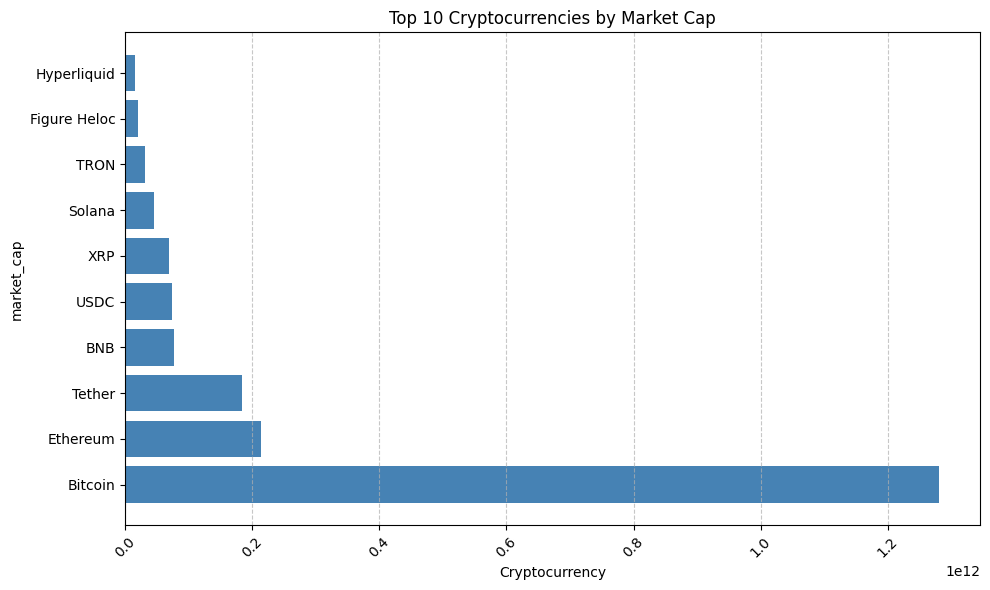

In [ ]:
top_10_market_cap

plt.figure(figsize=(10, 6))
plt.barh(top_10_market_cap.index, top_10_market_cap.values, color='steelblue')
plt.xlabel('Cryptocurrency')
plt.ylabel('market_cap')
plt.title('Top 10 Cryptocurrencies by Market Cap')
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/top_market_cap.png", dpi=300, bbox_inches="tight")
plt.show()

##2.Top 10 Trading Volume

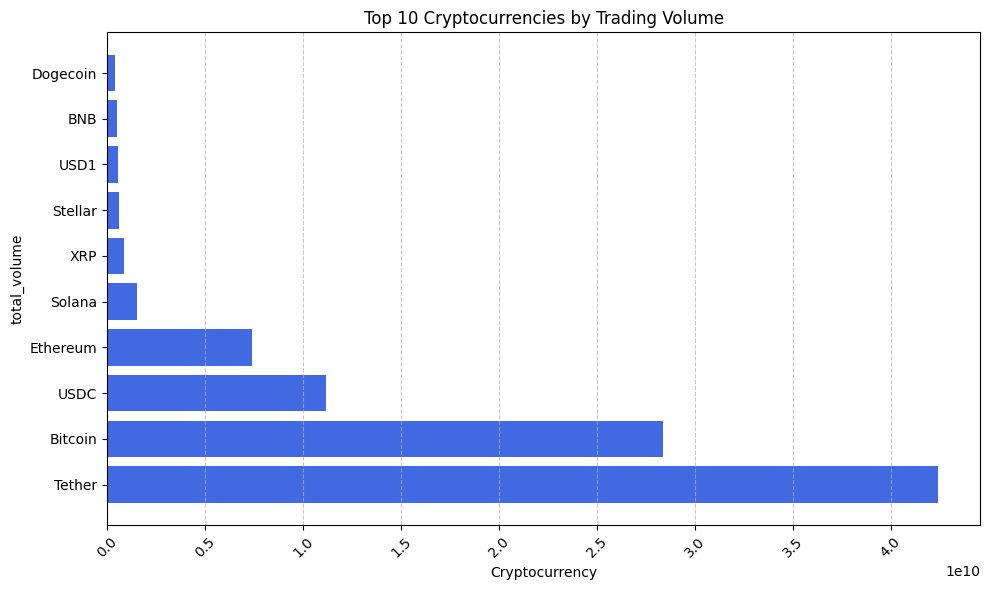

In [ ]:
top_10_trading_volume

plt.figure(figsize=(10, 6))
plt.barh(top_10_trading_volume.index, top_10_trading_volume.values, color='royalblue')
plt.xlabel('Cryptocurrency')
plt.ylabel('total_volume')
plt.title('Top 10 Cryptocurrencies by Trading Volume')
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/top_10_trading_volume.png", dpi=300, bbox_inches="tight")
plt.show()


##3.Top Gainers

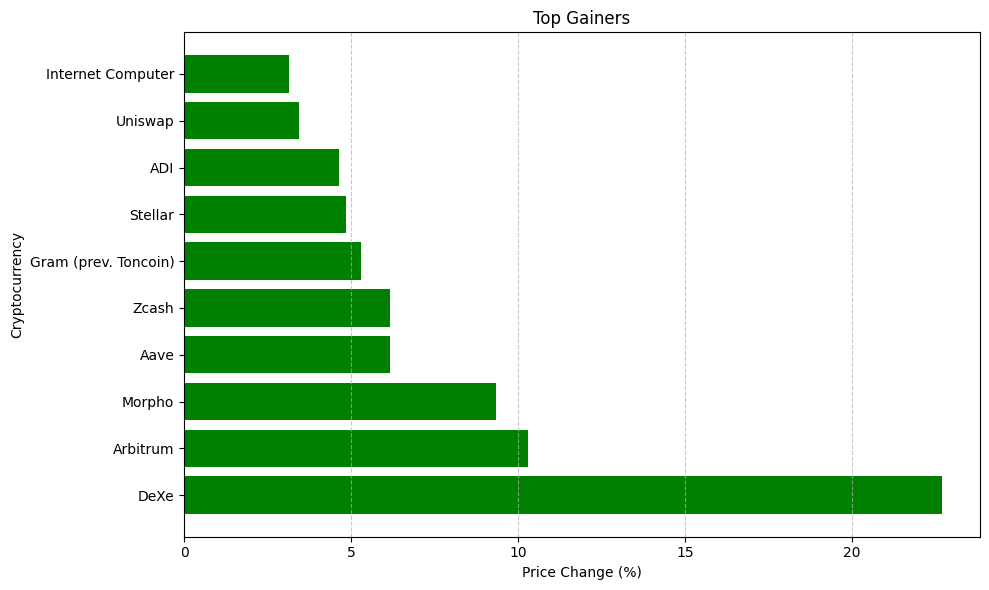

In [ ]:
top_10_gainers

plt.figure(figsize=(10, 6))
plt.barh(top_10_gainers['name'], top_10_gainers['price_change_percentage_24h'], color='green')
plt.xlabel('Price Change (%)')
plt.ylabel('Cryptocurrency')
plt.title('Top Gainers')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/top_10_gainers.png", dpi=300, bbox_inches="tight")
plt.show()

##4.Top Losers

/tmp/ipykernel_1456/2586841284.py:7: UserWarning: Glyph 24065 (\N{CJK UNIFIED IDEOGRAPH-5E01}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1456/2586841284.py:7: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1456/2586841284.py:7: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1456/2586841284.py:7: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1456/2586841284.py:8: UserWarning: Glyph 24065 (\N{CJK UNIFIED IDEOGRAPH-5E01}) missing from font(s) DejaVu Sans.
  plt.savefig("images/top_10_losers.png", dpi=300, bbox_inches="tight")
/tmp/ipykernel_1456/2586841284.py:8: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  plt.savefig("images/top_10_losers.png", dpi=300, bbox_inches="tight"

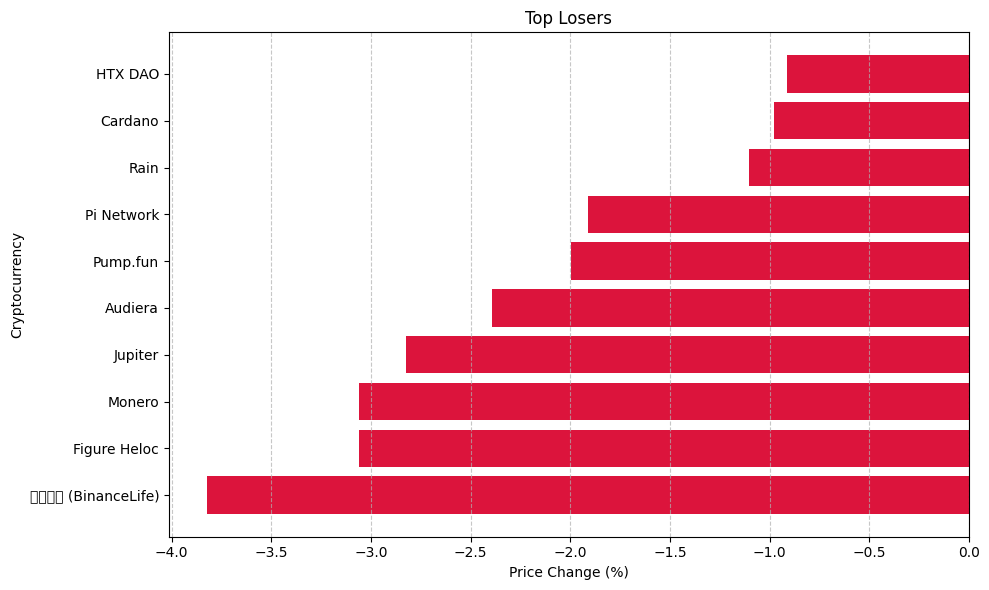

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top_10_losers['name'], top_10_losers['price_change_percentage_24h'], color='crimson')
plt.xlabel('Price Change (%)')
plt.ylabel('Cryptocurrency')
plt.title('Top Losers')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("images/top_10_losers.png", dpi=300, bbox_inches="tight")
plt.show()

##5.Market Cap Distribution

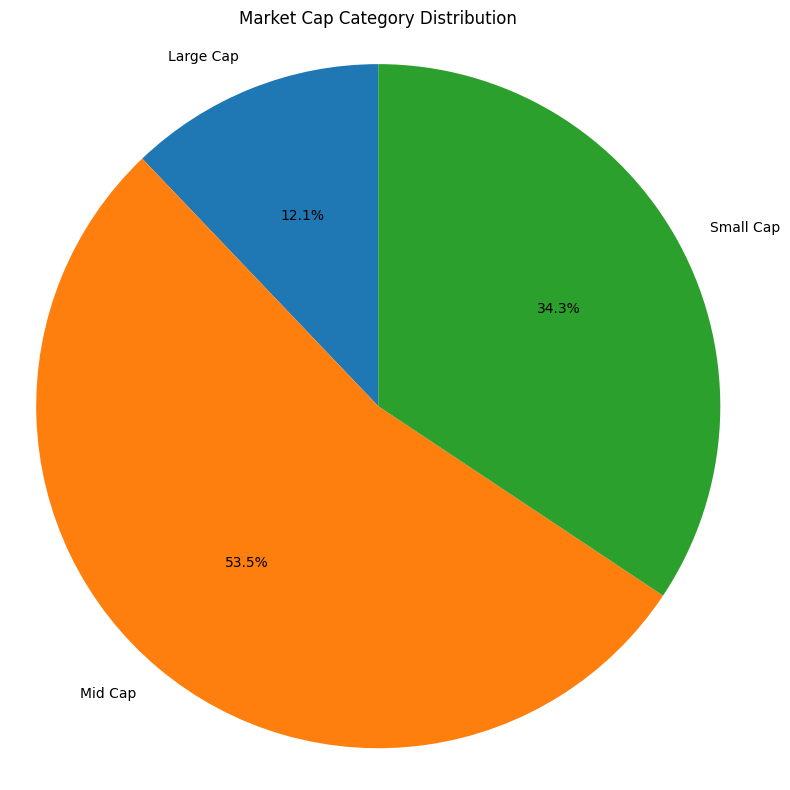

In [ ]:
market_cap_by_category

plt.figure(figsize=(8, 8))
plt.pie(
    market_cap_by_category['market_cap']['count'],
    labels=market_cap_by_category.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Market Cap Category Distribution')
plt.axis('equal')
plt.tight_layout()
plt.savefig("images/market_cap_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


##6.Supply Distribution


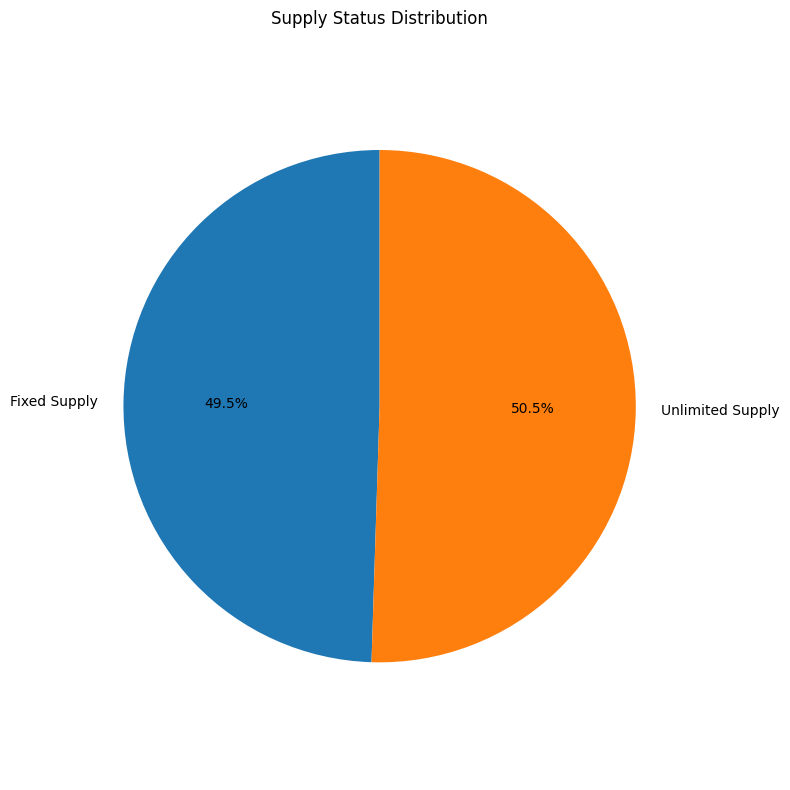

In [ ]:
supply_status_market

plt.figure(figsize=(8, 8))
plt.pie(
    supply_status_market['count'],
    labels=supply_status_market.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Supply Status Distribution')
plt.axis('equal')
plt.tight_layout()
plt.savefig("images/supply_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

##7.Price Distribution

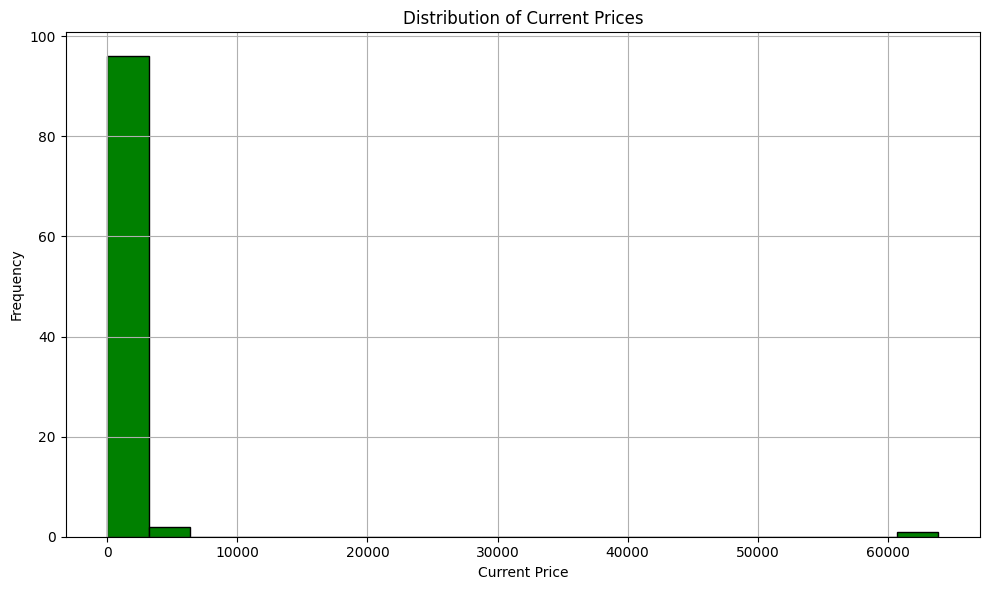

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(
    df['current_price'],
    bins=20,
    color='green',
    edgecolor='black'
)
plt.xlabel('Current Price')
plt.ylabel('Frequency')
plt.title('Distribution of Current Prices')
plt.grid(True)
plt.tight_layout()
plt.savefig("images/price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

##8.Correlation Heatmap

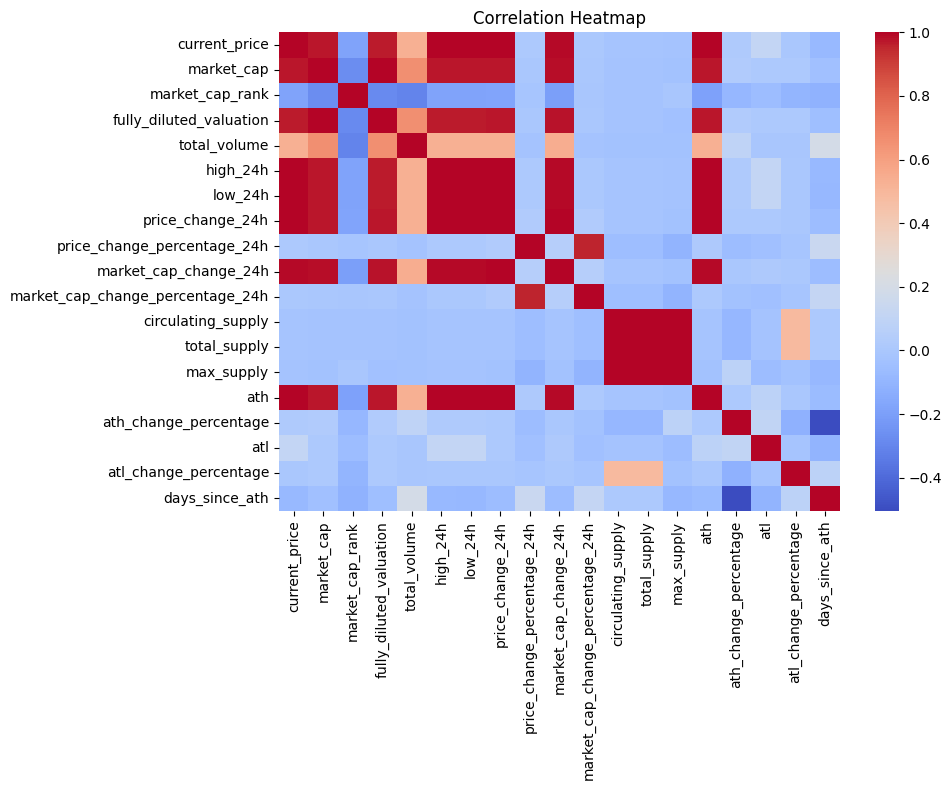

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    fmt=".1f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

##9.Market Cap vs Trading Volume

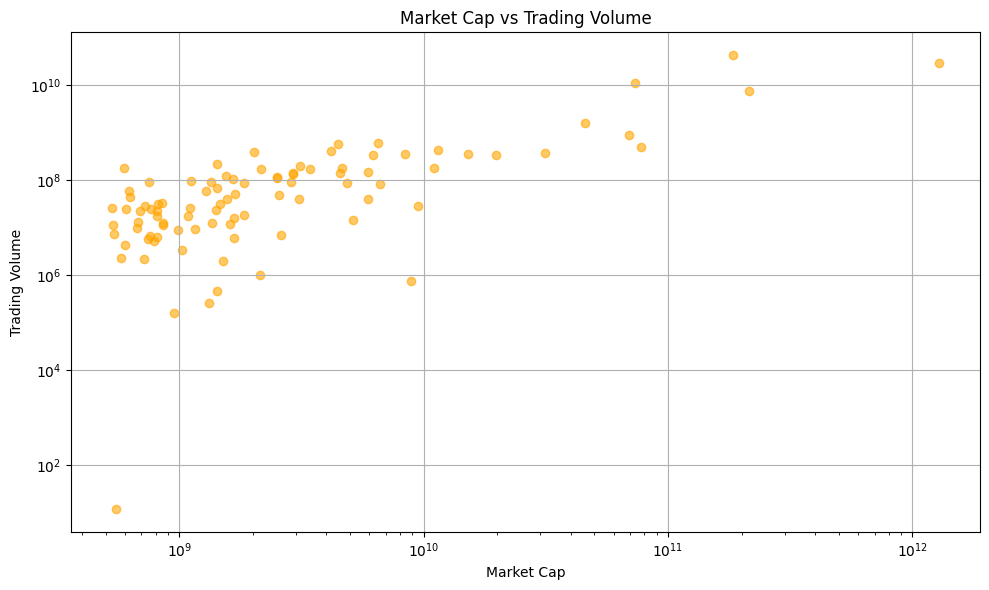

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df['market_cap'],
    df['total_volume'],
    alpha=0.6,
    color='orange'
)
plt.xlabel('Market Cap')
plt.ylabel('Trading Volume')
plt.title('Market Cap vs Trading Volume')
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.savefig("images/market_cap_vs_trading_volume.png", dpi=300, bbox_inches="tight")
plt.show()

##10.Days Since ATH

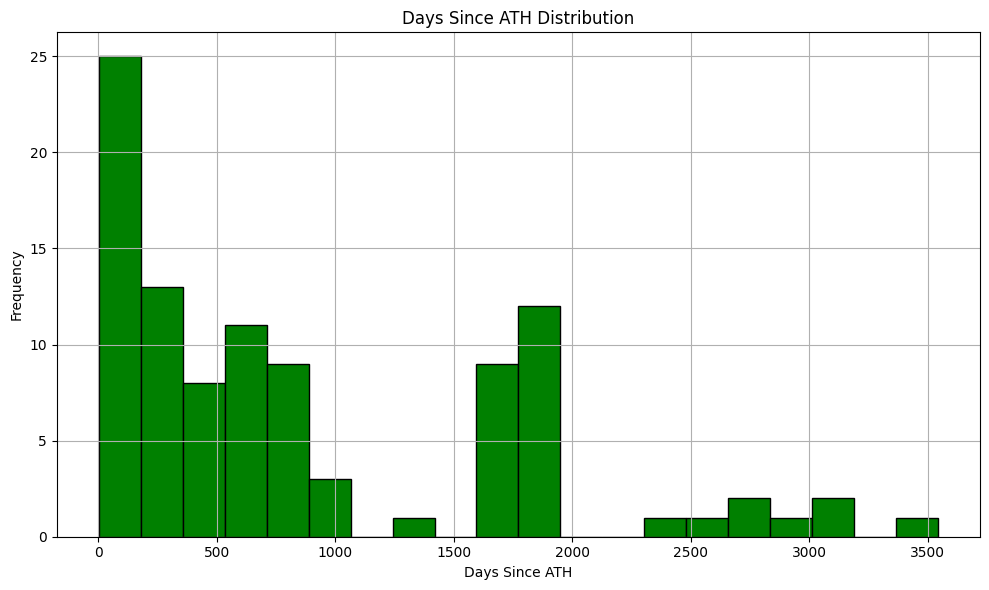

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(
    df['days_since_ath'],
    bins=20,
    color='green',
    edgecolor='black'
)
plt.xlabel('Days Since ATH')
plt.ylabel('Frequency')
plt.title('Days Since ATH Distribution')
plt.grid(True)
plt.tight_layout()
plt.savefig("images/days_since_ath_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#10.Business Insights

1. Bitcoin accounts for the largest market capitalization among the top 100 cryptocurrencies analyzed.

2. Large-cap cryptocurrencies contribute the majority of the overall market value.

3. Most cryptocurrencies are currently trading well below their all-time highs.

4. Unlimited-supply cryptocurrencies represent a significant portion of the top 100 coins.

5. Trading volume shows a positive relationship with market capitalization.

6. Only a subset of cryptocurrencies experienced positive price movement in the last 24 hours.

7. Mid-cap cryptocurrencies represent the largest category within the analyzed dataset.

8. The cryptocurrency market exhibits a wide variation in current prices, ranging from fractions of a dollar to tens of thousands of dollars.

9. A small number of cryptocurrencies account for a large share of the total market capitalization.

10. Feature engineering enabled more meaningful analysis by classifying supply status, market-cap tiers, and daily price movement.

#11.Conclusion

This project demonstrates an end-to-end cryptocurrency market analysis pipeline using live data from the CoinGecko API.

Key achievements:

- Extracted live cryptocurrency data using REST API.
- Cleaned and prepared the dataset for analysis.
- Created business-focused engineered features.
- Performed exploratory data analysis to identify market trends.
- Built visualizations to communicate insights effectively.

The project showcases practical skills in API integration, data wrangling, feature engineering, exploratory data analysis, and data visualization using Python.

#12.Save Cleaned Dataset

In [ ]:
df.to_csv("crypto_cleaned.csv", index=False)